# Restaurant Margin & COGS Analysis

A small analytics project exploring **gross margin, COGS %, product profitability, menu mix, and channel/promotion impact** for a fictional quick-service restaurant group.

> **Data note:** this uses a **synthetic sample dataset** generated in the notebook (no real company data). The dataset is built to resemble the shape of real point-of-sale data — menu items, units sold, sell price, unit cost, sales channel, and promotions — so the same analysis would run on a real export.

**Tools:** Python, Pandas, Matplotlib.

**Key questions:**
1. What is the overall gross margin, and how much is lost to cost of goods sold (COGS)?
2. Which menu items are most and least profitable?
3. How does the *menu mix* look — are the high-revenue items also the high-profit items?
4. How does margin differ between **dine-in** and **delivery** (where channel fees apply)?
5. What is the margin trade-off when items are **on promotion**?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
np.random.seed(42)  # reproducible sample data


## 1. Build the sample dataset

Each row is a day's sales of one menu item through one channel. `unit_price` is what the customer pays; `unit_cost` is the food cost of making it (the COGS input).

In [2]:
menu = [
    # item,            category,   price, unit_cost
    ("Lamb Souvlaki",   "Mains",    16.50, 6.20),
    ("Chicken Souvlaki","Mains",    15.00, 4.80),
    ("Halloumi Wrap",   "Mains",    14.00, 5.10),
    ("Greek Salad",     "Sides",     9.50, 2.70),
    ("Chips & Feta",    "Sides",     8.00, 1.90),
    ("Baklava",         "Desserts",  6.50, 1.40),
    ("Greek Yoghurt",   "Desserts",  5.50, 1.60),
    ("Soft Drink",      "Drinks",    4.00, 0.70),
]
menu_df = pd.DataFrame(menu, columns=["item", "category", "unit_price", "unit_cost"])

dates = pd.date_range("2026-05-01", "2026-05-28", freq="D")
channels = ["Dine-in", "Delivery"]

rows = []
for d in dates:
    for _, m in menu_df.iterrows():
        for ch in channels:
            # base demand varies by item popularity and channel
            base = np.random.poisson(18 if m["category"] == "Mains" else 11)
            if ch == "Delivery":
                base = int(base * 0.7)  # fewer delivery orders
            promo = np.random.rand() < 0.15  # ~15% of item-days on promo
            units = int(base * (1.6 if promo else 1.0))  # promo lifts volume
            price = round(m["unit_price"] * (0.85 if promo else 1.0), 2)  # 15% off on promo
            rows.append({
                "date": d, "item": m["item"], "category": m["category"],
                "channel": ch, "units_sold": units,
                "unit_price": price, "unit_cost": m["unit_cost"], "on_promo": promo,
            })

df = pd.DataFrame(rows)
df.head()


,date,item,category,channel,units_sold,unit_price,unit_cost,on_promo
0,2026-05-01,Lamb Souvlaki,Mains,Dine-in,21,16.50,6.20,False
1,2026-05-01,Lamb Souvlaki,Mains,Delivery,9,16.50,6.20,False
2,2026-05-01,Chicken Souvlaki,Mains,Dine-in,30,12.75,4.80,True
3,2026-05-01,Chicken Souvlaki,Mains,Delivery,9,15.00,4.80,False
4,2026-05-01,Halloumi Wrap,Mains,Dine-in,15,14.00,5.10,False


## 2. Calculate the margin metrics

The core formulas every margin analyst uses:

- **Revenue** = units sold x price
- **COGS** (cost of goods sold) = units sold x unit cost
- **Gross profit** = revenue - COGS
- **Gross margin %** = gross profit / revenue

A **delivery channel fee** is also applied to delivery orders, because aggregator/commission fees eat directly into margin — a key reason delivery is usually less profitable than dine-in.

In [3]:
DELIVERY_FEE_RATE = 0.18  # ~18% commission on delivery revenue

df["revenue"] = df["units_sold"] * df["unit_price"]
df["cogs"] = df["units_sold"] * df["unit_cost"]
df["channel_fee"] = np.where(df["channel"] == "Delivery", df["revenue"] * DELIVERY_FEE_RATE, 0.0)
df["gross_profit"] = df["revenue"] - df["cogs"] - df["channel_fee"]

total_rev = df["revenue"].sum()
total_cogs = df["cogs"].sum()
total_fees = df["channel_fee"].sum()
total_gp = df["gross_profit"].sum()

print(f"Total revenue:        ${total_rev:,.0f}")
print(f"Total COGS:           ${total_cogs:,.0f}  ({total_cogs/total_rev:.1%} of revenue)")
print(f"Delivery fees:        ${total_fees:,.0f}  ({total_fees/total_rev:.1%} of revenue)")
print(f"Gross profit:         ${total_gp:,.0f}")
print(f"Overall gross margin: {total_gp/total_rev:.1%}")


Total revenue:        $58,603
Total COGS:           $19,515  (33.3% of revenue)
Delivery fees:        $4,163  (7.1% of revenue)
Gross profit:         $34,925
Overall gross margin: 59.6%


## 3. Product profitability — which items earn their place?

Margin % alone can mislead: a high-margin item that barely sells matters less than a slightly-lower-margin item that sells in volume. So we look at both **gross margin %** and **total gross profit** per item.

In [4]:
by_item = df.groupby("item").agg(
    units=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    cogs=("cogs", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index()
by_item["gross_margin_pct"] = by_item["gross_profit"] / by_item["revenue"]
by_item["cogs_pct"] = by_item["cogs"] / by_item["revenue"]
by_item = by_item.sort_values("gross_profit", ascending=False)
by_item


,item,units,revenue,cogs,gross_profit,gross_margin_pct,cogs_pct
1,Chicken Souvlaki,919,"13,411.50","4,411.20","8,075.69",0.60,0.33
6,Lamb Souvlaki,920,"14,693.41","5,704.00","7,910.04",0.54,0.39
5,Halloumi Wrap,931,"12,542.60","4,748.10","6,941.86",0.55,0.38
3,Greek Salad,601,"5,460.68","1,622.70","3,441.06",0.63,0.30
2,Chips & Feta,518,"3,996.40",984.20,"2,720.31",0.68,0.25
0,Baklava,533,"3,365.52",746.20,"2,381.09",0.71,0.22
4,Greek Yoghurt,579,"3,054.19",926.40,"1,895.60",0.62,0.30
7,Soft Drink,532,"2,078.80",372.40,"1,559.20",0.75,0.18


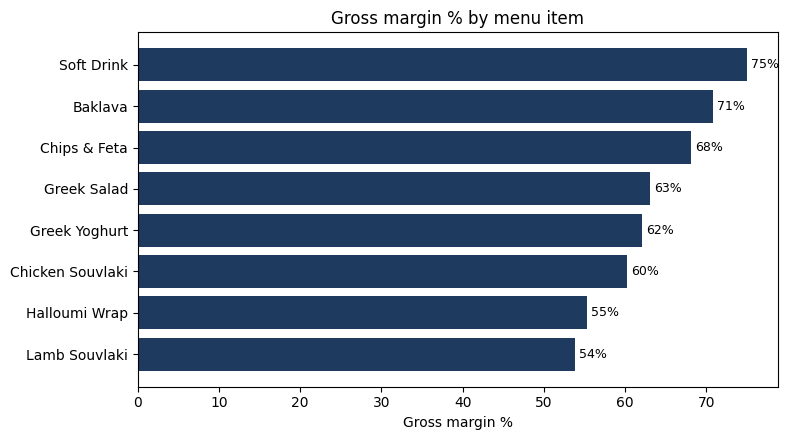

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = by_item.sort_values("gross_margin_pct")
ax.barh(order["item"], order["gross_margin_pct"] * 100, color="#1F3A5F")
ax.set_xlabel("Gross margin %")
ax.set_title("Gross margin % by menu item")
for i, v in enumerate(order["gross_margin_pct"] * 100):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()


## 4. Menu mix — do our top sellers also drive profit?

Comparing each item's **share of revenue** with its **share of gross profit** flags items that sell well but contribute little profit (low-margin volume) versus quiet items that punch above their weight.

In [6]:
mix = by_item.copy()
mix["rev_share"] = mix["revenue"] / mix["revenue"].sum()
mix["profit_share"] = mix["gross_profit"] / mix["gross_profit"].sum()
mix["mix_gap_pp"] = (mix["profit_share"] - mix["rev_share"]) * 100  # +ve = over-delivers on profit
mix[["item", "rev_share", "profit_share", "mix_gap_pp"]].sort_values("mix_gap_pp", ascending=False)


,item,rev_share,profit_share,mix_gap_pp
0,Baklava,0.06,0.07,1.07
2,Chips & Feta,0.07,0.08,0.97
7,Soft Drink,0.04,0.04,0.92
3,Greek Salad,0.09,0.10,0.53
1,Chicken Souvlaki,0.23,0.23,0.24
4,Greek Yoghurt,0.05,0.05,0.22
5,Halloumi Wrap,0.21,0.20,-1.53
6,Lamb Souvlaki,0.25,0.23,-2.42


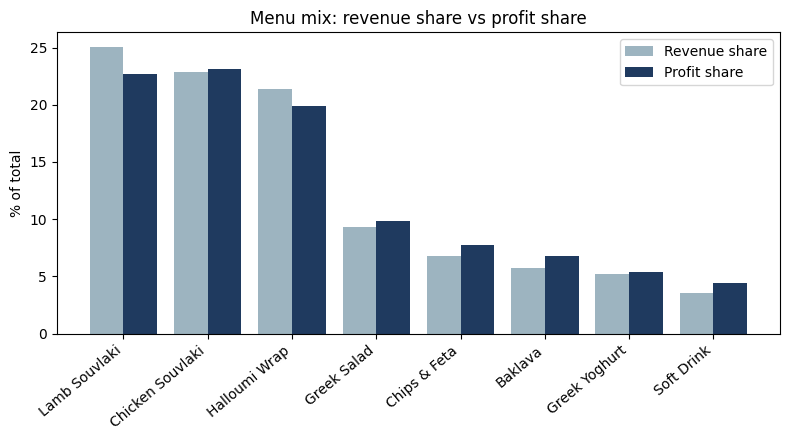

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
m = mix.sort_values("revenue", ascending=False)
x = np.arange(len(m)); w = 0.4
ax.bar(x - w/2, m["rev_share"] * 100, w, label="Revenue share", color="#9DB4C0")
ax.bar(x + w/2, m["profit_share"] * 100, w, label="Profit share", color="#1F3A5F")
ax.set_xticks(x); ax.set_xticklabels(m["item"], rotation=40, ha="right")
ax.set_ylabel("% of total"); ax.set_title("Menu mix: revenue share vs profit share")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Channel margin — dine-in vs delivery

Delivery typically sells less *and* keeps less of each dollar once commission fees are applied. Quantifying that gap informs decisions on delivery pricing, minimum order values, or menu availability by channel.

In [8]:
by_channel = df.groupby("channel").agg(
    revenue=("revenue", "sum"),
    cogs=("cogs", "sum"),
    fees=("channel_fee", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index()
by_channel["gross_margin_pct"] = by_channel["gross_profit"] / by_channel["revenue"]
by_channel


,channel,revenue,cogs,fees,gross_profit,gross_margin_pct
0,Delivery,"23,128.10","7,664.10","4,163.06","11,300.94",0.49
1,Dine-in,"35,475.00","11,851.10",0.00,"23,623.90",0.67


## 6. Promotion impact — volume vs margin trade-off

Promotions lift units sold but cut the margin on each unit. The question is whether the extra volume makes up for the thinner margin.

In [9]:
by_promo = df.groupby("on_promo").agg(
    units=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index()
by_promo["gross_margin_pct"] = by_promo["gross_profit"] / by_promo["revenue"]
by_promo["label"] = np.where(by_promo["on_promo"], "On promo", "Full price")
by_promo[["label", "units", "revenue", "gross_profit", "gross_margin_pct"]]


,label,units,revenue,gross_profit,gross_margin_pct
0,Full price,4299,"47,128.00","28,521.00",0.61
1,On promo,1234,"11,475.10","6,403.84",0.56


## Takeaways

- The headline gross margin is healthy, but **COGS and delivery fees** are the two biggest drains — worth tracking weekly.
- **Mains** drive most gross profit; some low-margin items pull their profit share below their revenue share (menu-mix candidates to reprice or rework).
- **Delivery margin sits well below dine-in** once commission is applied — a lever for channel pricing or minimum-order rules.
- **Promotions** trade margin % for volume; they only pay off where the extra units outweigh the thinner per-unit profit.

*Next steps on real data: add supplier-cost movements over time, waste/wastage, and contribution margin after labour.*